2025-06-20 15:00:29.169883: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-20 15:00:29.229726: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-20 15:00:29.229764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-20 15:00:29.231294: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-20 15:00:29.240226: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
data ['LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_200316_001_  5', 'Simulation_01_200428_001_005', 'Simulation_01_200212_001_  7', 'LA_RSPV_150113', 'Simulation_01_210205_001_003', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_200428_001_003', 'LA_LSPV_150113', 'RA_RAFW_140807', 'Simulation_01_200316_001_  3', 'RA_RAA_141230', 'Sinusal_150629', 'Simulation_01_200212_001_  9', 'Simulation_01_200316_001_  1', 'Simulation_01_200428_001_007', 'Simulation_01_200428_001_009', 'Simulation_01_200212_001_  5', 'Simulation_01_210209_001_003', 'LA_RIPV_150121', 'LA_LIPV_150119', 'Simulation_01_200316_001_  9']
models_names ['LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_200316_001_  5', 'Simulation_01_200428_001_005', 'Simulation_01_200212_001_  7', 'LA_RSPV_150113', 'Simulation_01_210205_001_003', 'S

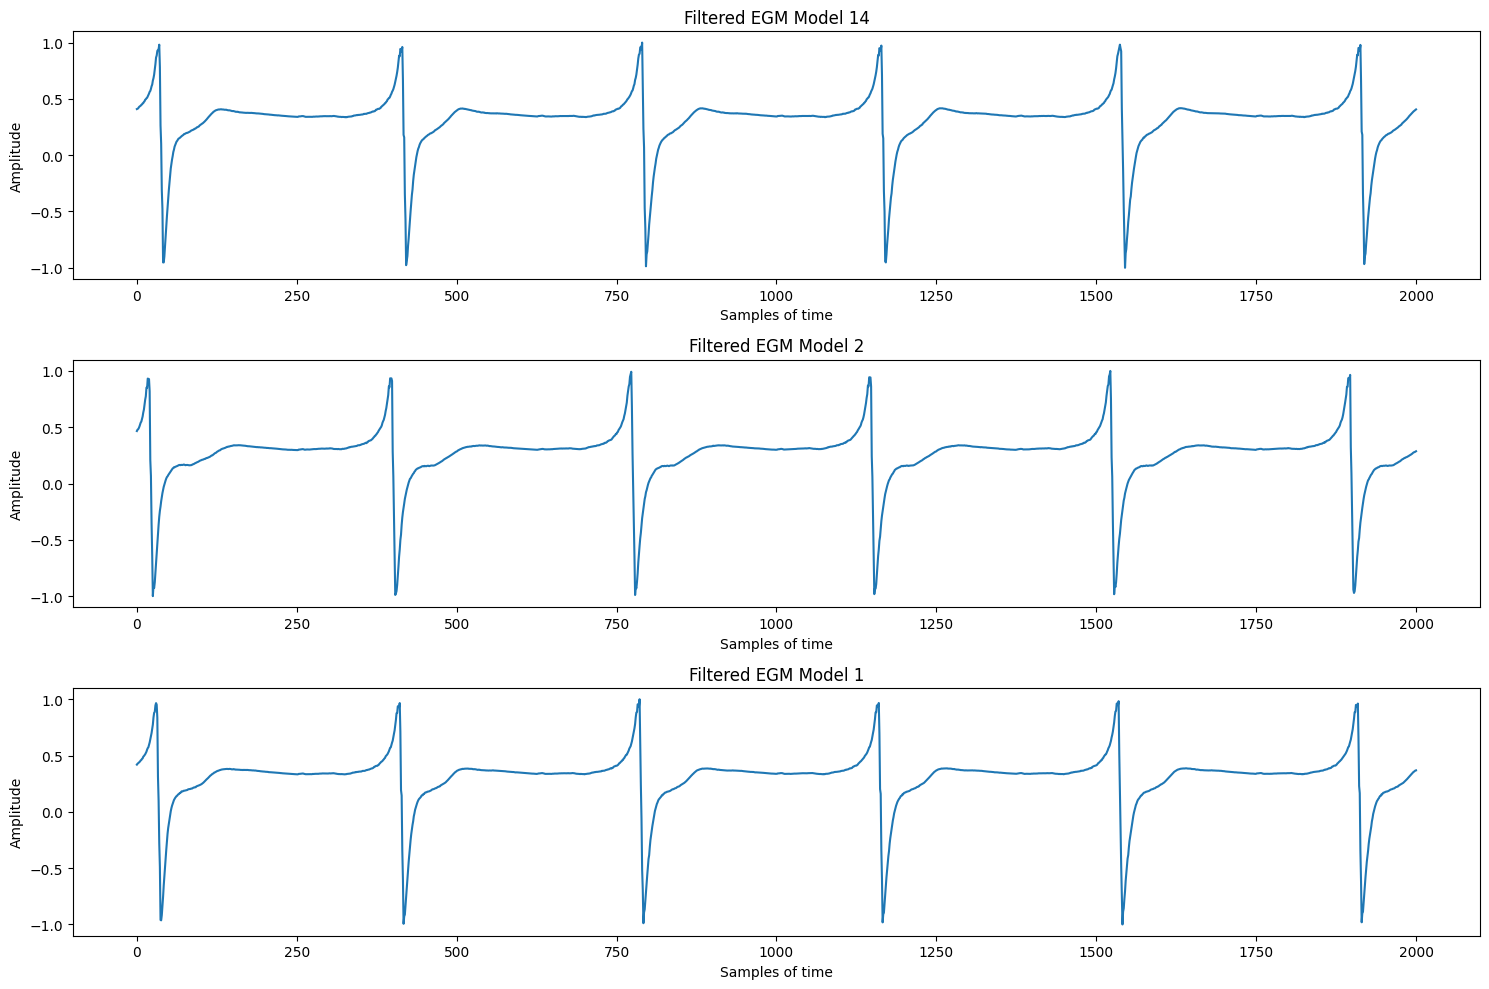

10
Transfer matrices LOADED - var: **transfer_matrices** 
BSPS Models LOADED - var: **bsps_all_models** 
BSPS 64 Models LOADED - var: **bsps_64_all_models** 
210
(3610, 2499)
(3610, 2499)
(64, 2499)
(3970, 2499)
(64, 2499)
(64, 2001)
210
BSPS 64 Models LOADED - var: **bsps_64_all_models** 


In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/alumnos/mburgosc/cuda-fake"

import tensorflow as tf

import tensorflow as tf 
import numpy as np
gpus = tf.config.list_physical_devices("GPU")

print(gpus)

import import_data

egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices
models_names = import_data.models_names
bsps_64_all_models_names = import_data.bsps_64_all_models_names

In [2]:
models_name_full = bsps_64_all_models_names

print(len(models_name_full))  

filtered_models = []
filtered_models_names = []

for model, name_model in zip(bsps_64_all_models, models_name_full):
    new_model = []

    for node in model:
        original_length = len(node)

        if original_length < 2000:
            continue

        if 2001 <= original_length <= 2500:
            node = node[:2000]
        elif 4001 <= original_length <= 4501:
            node = node[:4000]

        new_model.append(node)

    if len(new_model) > 0:
        filtered_models.append(new_model)
        filtered_models_names.append(name_model)  # Añadimos el nombre del modelo
    bsps_64_filtered_models = filtered_models

print(len(bsps_64_filtered_models))
print(len(filtered_models_names))
print(filtered_models_names)

print(filtered_models_names[140])

210
210
210
['LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200212_001_  7', 'Simulation_01_200212_001_  7', 'Simulation_01_200212_001_  7', 'Simulation_01_200212_001_  7',

In [3]:
import pandas as pd

# Lee CSV de anotaciones
csv_df = pd.read_csv('annotations.csv', header=None)
csv_split = csv_df[0].str.split(';', expand=True)
csv_names = csv_split[0].tolist()
csv_labels = csv_split[1].astype(int).tolist()

# Mapea nombres a etiquetas binarias
name_to_label = {}
for name, label in zip(csv_names, csv_labels):
    if label == 4:
        name_to_label[name] = 0  # Sinusal
    elif label == 3:
        name_to_label[name] = 1  # AF

# Genera lista de etiquetas para cada modelo
filtered_labels = [name_to_label[name] for name in filtered_models_names]
print(filtered_labels)  
print(len(filtered_labels))

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
210


In [4]:
from collections import OrderedDict
import random
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
import numpy as np

modelos_unicos = list(OrderedDict.fromkeys(filtered_models_names)) # NOMBRES DE LOS 21 MODELOS UNICOS
print((modelos_unicos)) 


model_labels_dict = {}                                             # DICCIONARIO CON NOMBRES DE MODELOS Y SUS ETIQUETAS
for name, label in zip(filtered_models_names, filtered_labels):
    if name not in model_labels_dict:
        model_labels_dict[name] = label
print(model_labels_dict)
print(len(model_labels_dict))  


model_to_indices = {m: [] for m in modelos_unicos}  # DICCIONARIO CON NOMBRES DE MODELOS Y SUS INDICES EN filtered_models_names
for i, name in enumerate(filtered_models_names):
    if name in modelos_unicos:
        model_to_indices[name].append(i)
print(f"Índices de modelos: {model_to_indices}")


# DIVIDIR MODELOS UNICOS EN TRAIN Y TEST
train_models, test_models = train_test_split(modelos_unicos, test_size=0.3, random_state=42)

print("train and test models:")
print(train_models)
print(test_models)


# INDICES DE LOS MODELOS EN EL CONJUNTO DE MODELOS
train_indices = [i for model in train_models for i in model_to_indices[model]]
test_indices = [i for model in test_models for i in model_to_indices[model]]
print("train and test indices:")
print(train_indices)
print(test_indices)


X_train, y_train, groups_train = [], [], []
X_test, y_test, groups_test = [], [], []

# PARA DIVIDIR EN SEGMENTOS LOS MODELOS 
def split_models_in_half(indices, target_X, target_y, target_g):
    for idx in indices:
        model_name = filtered_models_names[idx]
        label = model_labels_dict[model_name]
        model_data = np.array(filtered_models[idx])  # (64, 2000)

        # Verifica que tenga 2000 samples para dividir en dos mitades de 1000
        if model_data.shape[1] != 2000:
            print(f"Modelo con longitud inesperada: {model_data.shape} - se omite")
            continue

        # Corta el modelo en dos mitades de 1000 samples, manteniendo los 64 nodos
        first_half = model_data[:, :1000]
        second_half = model_data[:, 1000:]

        # Guarda ambos fragmentos con su label y nombre de modelo
        target_X.extend([first_half, second_half])
        target_y.extend([label, label])
        target_g.extend([model_name, model_name])

split_models_in_half(train_indices, X_train, y_train, groups_train)
split_models_in_half(test_indices, X_test, y_test, groups_test)


X_train = np.array(X_train)
y_train = np.array(y_train)
groups_train = np.array(groups_train)

X_test = np.array(X_test)
y_test = np.array(y_test)
groups_test = np.array(groups_test)


print(f"Distribución train: {Counter(y_train)}")
print(f"Distribución test: {Counter(y_test)}")
print(f"Shapes: X_train={X_train.shape}, X_test={X_test.shape}")


print(Counter(y_train))
print(f"Datos de entrenamiento: {X_train.shape}, etiquetas: {y_train.shape}, grupos: {groups_train.shape}")
print(f"Datos de prueba: {X_test.shape}, etiquetas: {y_test.shape}, grupos: {groups_test.shape}")


print(y_train)
print(list(OrderedDict.fromkeys((groups_train))))
print(groups_train)

print(Counter(y_test))


['LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_200428_001_005', 'Simulation_01_200212_001_  7', 'LA_RSPV_150113', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_200428_001_003', 'LA_LSPV_150113', 'RA_RAFW_140807', 'Simulation_01_200316_001_  3', 'RA_RAA_141230', 'Sinusal_150629', 'Simulation_01_200212_001_  9', 'Simulation_01_200316_001_  1', 'Simulation_01_200428_001_007', 'Simulation_01_200428_001_009', 'Simulation_01_200212_001_  5', 'LA_RIPV_150121', 'LA_LIPV_150119', 'Simulation_01_200316_001_  9']
{'LA_RSPV_CAF_150115': 1, 'Simulation_01_200316_001_  5': 0, 'Simulation_01_200428_001_005': 0, 'Simulation_01_200212_001_  7': 0, 'LA_RSPV_150113': 1, 'Simulation_01_200212_001_  1': 0, 'LA_LSPV_150203': 1, 'Simulation_01_200428_001_003': 0, 'LA_LSPV_150113': 1, 'RA_RAFW_140807': 1, 'Simulation_01_200316_001_  3': 0, 'RA_RAA_141230': 1, 'Sinusal_150629': 0, 'Simulation_01_200212_001_  9': 0, 'Simulation_01_200316_001_  1': 0, 'Simulation_01_2004

In [5]:
# FUNCTIONS --> ADD_NOISE + FILTERING
from scipy.signal import butter, filtfilt
from add_white_noise import addwhitenoise

# Parámetros
fs = 500  # Frecuencia de muestreo
cutoff = 40  # Frecuencia de corte del filtro LPF

# Función para crear y aplicar un filtro paso bajo
def lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs  # Frecuencia de Nyquist
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

# Selecciona el modelo

def extract_filtered_data(X, fs, SNR, cutoff):
    filtered_data = []
    for model in X:
        model = np.array(model)
        model = model - np.mean(model, axis=1, keepdims=True)  # Centrado
        model_noisy_T, _ = addwhitenoise(model, SNR=SNR, fs=fs, plot_figure='False')
        model_noisy = model_noisy_T
        senal_filtrada = lowpass_filter(model_noisy, cutoff=cutoff, fs=fs)
        filtered_data.append(senal_filtrada)
    return np.array(filtered_data)

X_train_filt_10dB = extract_filtered_data(X_train, fs=500, SNR=10, cutoff=40)
X_test_filt_10dB = extract_filtered_data(X_test, fs=500, SNR=10, cutoff=40)

print(f"Datos filtrados: {X_train_filt_10dB.shape}, {X_test_filt_10dB.shape}")

X_train_filt_20dB = extract_filtered_data(X_train, fs=500, SNR=20, cutoff=40)
X_test_filt_20dB = extract_filtered_data(X_test, fs=500, SNR=20, cutoff=40)

print(f"Datos filtrados: {X_train_filt_10dB.shape}, {X_test_filt_10dB.shape}")


Datos filtrados: (280, 64, 1000), (140, 64, 1000)
Datos filtrados: (280, 64, 1000), (140, 64, 1000)


Original data: 95% variance → 2 components
Original data: 99% variance → 4 components
Noise filtered data (SNR=10 dB): 95% variance → 4 components
Noise filtered data (SNR=10 dB): 99% variance → 14 components
Noise filtered data (SNR=20 dB): 95% variance → 4 components
Noise filtered data (SNR=20 dB): 99% variance → 7 components


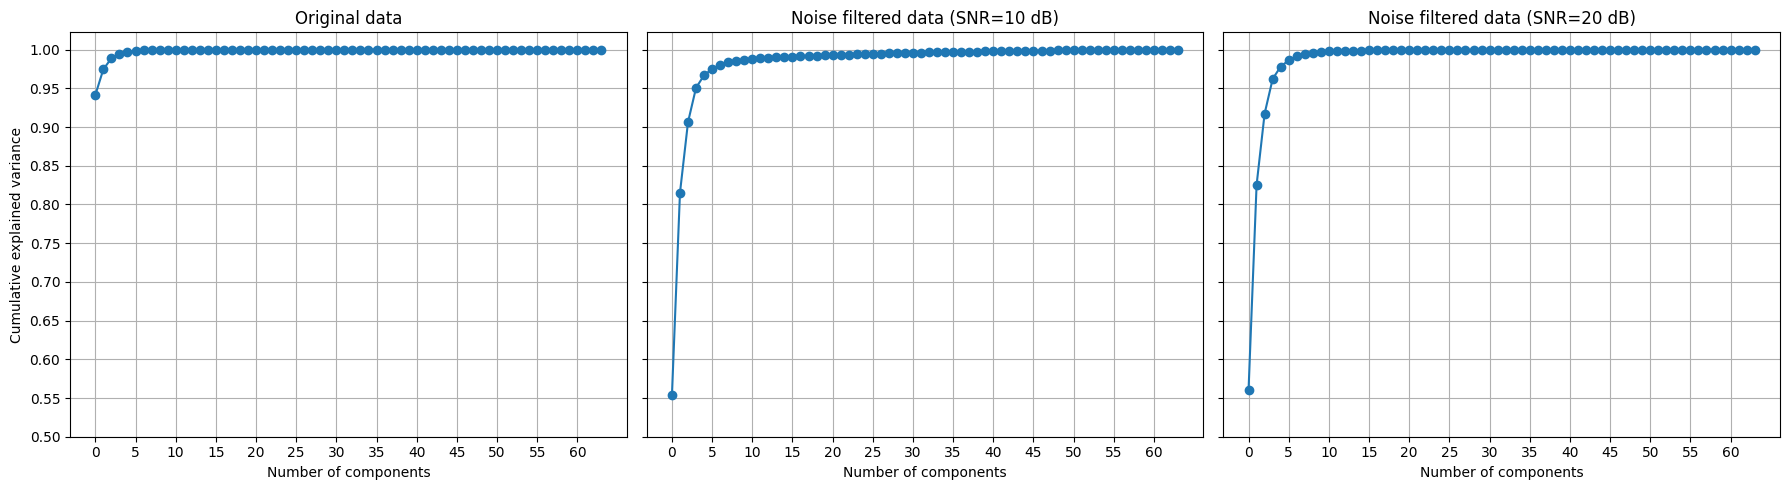

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Lista con tus datasets
datasets = {
    "Original data": X_train,
    "Noise filtered data (SNR=10 dB)": X_train_filt_10dB,
    "Noise filtered data (SNR=20 dB)": X_train_filt_20dB
}

# Configuración
np.random.seed(42)
thresholds = [0.95, 0.99]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)  # 1 fila, 3 columnas

# Recorremos cada conjunto de datos
for i, (label, data) in enumerate(datasets.items()):
    num_models = len(X_train)
    total_models = data.shape[0]

    # Selección aleatoria de modelos
    random_indices = np.random.choice(total_models, size=num_models, replace=False)
    all_cum_var = []

    # PCA por modelo
    for idx in random_indices:
        model = data[idx]  # shape: (64, 1000)
        pca = PCA()
        pca.fit(model)
        cum_var = np.cumsum(pca.explained_variance_ratio_)
        all_cum_var.append(cum_var)

    all_cum_var = np.array(all_cum_var)
    mean_cum_var = np.mean(all_cum_var, axis=0)

    # Gráfico
    axes[i].plot(mean_cum_var, marker='o')
    axes[i].set_title(label)
    axes[i].set_xlabel('Number of components')
    axes[i].set_yticks(np.arange(0.5, 1.01, 0.05))
    axes[i].set_xticks(np.arange(0.0, 64, 5))
    if i == 0:
        axes[i].set_ylabel('Cumulative explained variance')
    axes[i].grid(True)

    # Calcular componentes para umbrales
    for t in thresholds:
        n_components = np.argmax(mean_cum_var >= t) + 1
        print(f"{label}: {t*100:.0f}% variance → {n_components} components")

plt.tight_layout()
plt.show()


In [7]:
# PRINCIPAL COMPONENT ANALYSIS (PCA)

from sklearn.decomposition import PCA

def apply_pca(X, n_components):
    # APLICAR PCA A CADA MODELO
    n_components = n_components  
    X_pca = []
    for model in X:
        model_T = model.T  # Transponer para que las muestras sean filas
        pca = PCA(n_components=n_components)
        model_pca = pca.fit_transform(model_T)  # (1000, 2)

        # Si quieres devolverlo como (64, 2) puedes transponer de nuevo
        model_pca = model_pca.T  # (2, 1000)
        X_pca.append(model_pca)

    return np.array(X_pca)

#original_data
X_train_pca = apply_pca(X_train, n_components=3)
X_test_pca = apply_pca(X_test, n_components=3)

#filtered_data_10dB
X_train_filt_10dB_pca = apply_pca(X_train_filt_10dB, n_components=3)
X_test_filt_10dB_pca = apply_pca(X_test_filt_10dB, n_components=3)

#filtered_data_20dB
X_train_filt_20dB_pca = apply_pca(X_train_filt_20dB, n_components=3)
X_test_filt_20dB_pca = apply_pca(X_test_filt_20dB, n_components=3)


print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_pca[0].shape} ")
print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_filt_10dB_pca[0].shape} ")
print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_filt_20dB_pca[0].shape} ")
print(f"No PCA applied. Ejemplo dimensiones: {X_train[0].shape} ")

PCA aplicado por modelo. Ejemplo dimensiones: (3, 1000) 
PCA aplicado por modelo. Ejemplo dimensiones: (3, 1000) 
PCA aplicado por modelo. Ejemplo dimensiones: (3, 1000) 
No PCA applied. Ejemplo dimensiones: (64, 1000) 


In [8]:
print(X_train_filt_20dB_pca.shape)

signal = X_train_pca[30][0]
print(len(signal))
print(y_train[30])

(280, 3, 1000)
1000
1


63
-21.454252274915557 -2.870966891032053
31


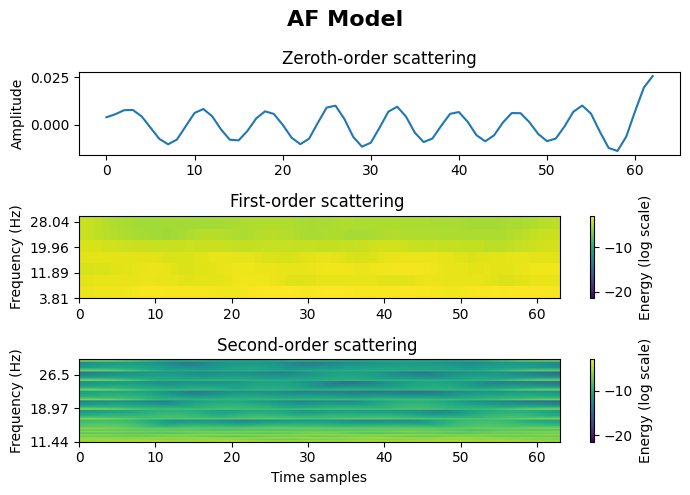

1
63
-18.312516614051837 -3.2808581602470843
31


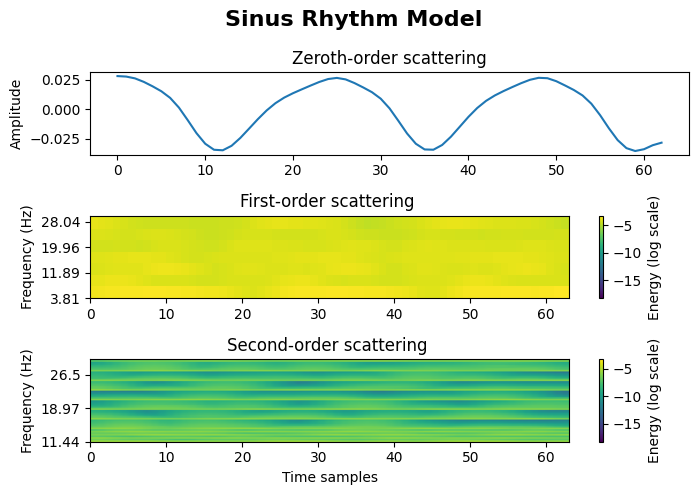

0


In [9]:
# FUNCION QUE APLICA WAVELET SCATTERING PERO ME ENSEÑA LAS FRECUENCIAS EN HZ EN LOS EJES
from kymatio import Scattering1D
def wavelet_scattering(signal, J, Q, fs, type_name=''):
    T = len(signal)
    scattering = Scattering1D(J=J, shape=(T,), Q=Q)
    
    # Obtener coeficientes de scattering y metadatos
    Sx = scattering(signal)
    meta = scattering.meta()

    order_0 = np.where(meta['order'] == 0)[0]
    order_1 = np.where(meta['order'] == 1)[0]
    order_2 = np.where(meta['order'] == 2)[0]
    print(len(Sx[order_0][0]))

    # Obtener frecuencias a partir de xi
    xi_order1 = meta['xi'][order_1, 0] * (fs / 2)
    xi_order2 = meta['xi'][order_2, 0] * (fs / 2)

    # Filtrar valores NaN
    xi_order1 = xi_order1[~np.isnan(xi_order1)]
    xi_order2 = xi_order2[~np.isnan(xi_order2)]

    # Redondear frecuencias para mejor visualización
    freq_order1 = np.round(xi_order1, 2)
    freq_order2 = np.round(xi_order2, 2)

    log_Sx1 = np.log10(Sx[order_1])
    log_Sx2 = np.log10(Sx[order_2])

    # Rango común para colorbars
    vmin = min(log_Sx1.min(), log_Sx2.min())
    vmax = max(log_Sx1.max(), log_Sx2.max())
    print(vmin, vmax)

    # Seleccionar solo algunas frecuencias para las etiquetas del eje Y
    num_ticks = 15 
    yticks_order1 = np.linspace(freq_order1[0], freq_order1[-1], num_ticks)
    yticks_order2 = np.linspace(freq_order2[0], freq_order2[-1], num_ticks)

    plt.figure(figsize=(7, 5))

    # Zeroth-order scattering
    plt.subplot(3, 1, 1)
    plt.plot(Sx[order_0][0])
    plt.title(f'Zeroth-order scattering')
    plt.ylabel('Amplitude')

    # First-order scattering
    plt.subplot(3, 1, 2)
    plt.imshow(np.log10(Sx[order_1]), aspect='auto', extent=[0, len(Sx[order_1][0]), freq_order1[-1], freq_order1[0]], vmin=vmin, vmax=vmax, cmap='viridis')
    plt.title(f'First-order scattering ')
    plt.ylabel('Frequency (Hz)')
    plt.yticks(yticks_order1, np.round(yticks_order1, 2))  
    plt.ylim(freq_order1[-1],30) # LIMITO EL EJE A FRECUENCIAS MENORES DE 40 HZ PORQUE ES DONDE ESTÁN LAS FRECUENCIAS DE INTERÉS
    plt.colorbar(label='Energy (log scale)')
    print(len(freq_order1))

    # Second-order scattering
    plt.subplot(3, 1, 3)
    plt.imshow(np.log10(Sx[order_2]), aspect='auto', extent=[0, len(Sx[order_2][0]), freq_order2[-1], freq_order2[0]], vmin=vmin, vmax=vmax, cmap='viridis')
    plt.title(f'Second-order scattering ')
    plt.ylabel('Frequency (Hz)')
    plt.yticks(yticks_order2, np.round(yticks_order2, 2))  
    plt.ylim(freq_order2[-1],30)
    plt.colorbar(label='Energy (log scale)')

    plt.xlabel('Time samples')

    plt.suptitle(f'{type_name}', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

fs = 500  # Ajusta según la frecuencia de tu señal
signal = X_train_pca[30][0]  # Ejemplo de señal
wavelet_scattering(signal, J=4, Q=(16,16), fs=500 , type_name='AF Model')
print(y_train[105])

#plt.figure(figsize=(7, 1))
#plt.plot(X_train_pca[30][0], label='Signal')


fs = 500  # Ajusta según la frecuencia de tu señal
signal = X_train_pca[50][0]  # Ejemplo de señal
wavelet_scattering(signal, J=4, Q=(16,16), fs=500, type_name='Sinus Rhythm Model' )
print(y_train[50])

#plt.figure(figsize=(7, 1))
#plt.plot(X_train_pca[50][0], label='Signal')

In [10]:
# WAVELET SCATTERING TRANSFORM

from kymatio import Scattering1D

def apply_wavelet_scattering(X, J=4, Q=(16, 16)):
    # APLICAR SCATTERING A CADA MODELO
    J = 4
    Q = (16,16)

    ws_coeffs = []  

    for model in X:
        model_coeffs = []  
        
        for j in range(len(model)):
            signal = np.array(model[j])  
            len_signal = len(signal)
            
            scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
            Sx = scattering(signal)  
            model_coeffs.append(Sx)  
        ws_coeffs.append(np.stack(model_coeffs))
    return np.array(ws_coeffs)

#original_data
X_train_ws = apply_wavelet_scattering(X_train_pca)
X_test_ws = apply_wavelet_scattering(X_test_pca)

#filtered_data_10dB
X_train_filt_10dB_ws = apply_wavelet_scattering(X_train_filt_10dB_pca)
X_test_filt_10dB_ws = apply_wavelet_scattering(X_test_filt_10dB_pca)

#filtered_data_20dB
X_train_filt_20dB_ws = apply_wavelet_scattering(X_train_filt_20dB_pca)
X_test_filt_20dB_ws = apply_wavelet_scattering(X_test_filt_20dB_pca)

#original_data NO PCA
X_train_ws_no_pca = apply_wavelet_scattering(X_train)
X_test_ws_no_pca = apply_wavelet_scattering(X_test)

print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_filt_10dB_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_filt_20dB_ws[0].shape} ")
print(f"✅ Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_ws_no_pca[0].shape} ")



Scattering aplicado por modelo. Ejemplo dimensiones: (3, 326, 63) 
Scattering aplicado por modelo. Ejemplo dimensiones: (3, 326, 63) 
Scattering aplicado por modelo. Ejemplo dimensiones: (3, 326, 63) 
✅ Scattering aplicado por modelo. Ejemplo dimensiones: (64, 326, 63) 


In [20]:
print(X_train_ws.shape)
print(X_train_ws_no_pca.shape)

(280, 3, 326, 63)
(280, 64, 326, 63)


In [12]:
print(f"Datos originales: {X_train.shape}, {X_test.shape}")
print(f"Datos filtrados 10dB: {X_train_filt_10dB.shape}, {X_test_filt_10dB.shape}")
print(f"Datos filtrados 20dB: {X_train_filt_20dB.shape}, {X_test_filt_20dB.shape}")
print(f"Datos PCA: {X_train_pca.shape}, {X_test_pca.shape}")

Datos originales: (280, 64, 1000), (140, 64, 1000)
Datos filtrados 10dB: (280, 64, 1000), (140, 64, 1000)
Datos filtrados 20dB: (280, 64, 1000), (140, 64, 1000)
Datos PCA: (280, 3, 1000), (140, 3, 1000)


In [13]:
X_train_final = X_train_ws.reshape(X_train_ws.shape[0], -1)
X_test_final = X_test_ws.reshape(X_test_ws.shape[0], -1)

X_train_filt_10dB_final = X_train_filt_10dB_ws.reshape(X_train_filt_10dB_ws.shape[0], -1)
X_test_filt_10dB_final = X_test_filt_10dB_ws.reshape(X_test_filt_10dB_ws.shape[0], -1)

X_train_filt_20dB_final = X_train_filt_20dB_ws.reshape(X_train_filt_20dB_ws.shape[0], -1)
X_test_filt_20dB_final = X_test_filt_20dB_ws.reshape(X_test_filt_20dB_ws.shape[0], -1)

X_train_no_pca_final = X_train_ws_no_pca.reshape(X_train_ws_no_pca.shape[0], -1)
X_test_no_pca_final = X_test_ws_no_pca.reshape(X_test_ws_no_pca.shape[0], -1)

print(f"Datos finales: {X_train_final.shape}, {X_test_final.shape}")
print(f"Datos finales filtrados 10dB: {X_train_filt_10dB_final.shape}, {X_test_filt_10dB_final.shape}")
print(f"Datos finales filtrados 20dB: {X_train_filt_20dB_final.shape}, {X_test_filt_20dB_final.shape}")
print(f"Datos finales sin PCA: {X_train_no_pca_final.shape}, {X_test_no_pca_final.shape}")

Datos finales: (280, 61614), (140, 61614)
Datos finales filtrados 10dB: (280, 61614), (140, 61614)
Datos finales filtrados 20dB: (280, 61614), (140, 61614)
Datos finales sin PCA: (280, 1314432), (140, 1314432)


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, log_loss, f1_score

def random_forest_100(X_train_final, y_train, X_test_final, y_test):
    rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, bootstrap=True, n_jobs=-1)

    rf.fit(X_train_final, y_train)

    # Predecir y evaluar en test
    y_pred = rf.predict(X_test_final)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    acc = accuracy_score(y_test, y_pred)
    y_proba = rf.predict_proba(X_test_final)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    log_loss_value = log_loss(y_test, y_proba)
    f1_score_value = f1_score(y_test, rf.predict(X_test_final))

    print(classification_report(y_test, y_pred))
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Sensitivity (Recall):", sensitivity)
    print("Specificity:", specificity)
    print("AUC-ROC:", roc_auc)
    print("Log loss:", log_loss_value)
    return rf

rf_original = random_forest_100(X_train_final, y_train, X_test_final, y_test)
rf_filtered_10dB = random_forest_100(X_train_filt_10dB_final, y_train, X_test_filt_10dB_final, y_test)
rf_filtered_20dB = random_forest_100(X_train_filt_20dB_final, y_train, X_test_filt_20dB_final, y_test)
rf_no_pca = random_forest_100(X_train_no_pca_final, y_train, X_test_no_pca_final, y_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        60

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140

Accuracy: 1.0
Confusion Matrix:
 [[80  0]
 [ 0 60]]
Sensitivity (Recall): 1.0
Specificity: 1.0
AUC-ROC: 1.0
Log loss: 0.037162883340659085
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        60

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140

Accuracy: 1.0
Confusion Matrix:
 [[80  0]
 [ 0 60]]
Sensitivity (Recall): 1.0
Specificity: 1.0
AUC-ROC: 1.0
Log loss: 0.06907788250875628
              precision    recall  f1-score   support

           0  

In [15]:
"""from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
def tunning_random_forest(X_train_final, y_train, rf):
    # Inicializar el modelo Random Forest
    # Definir la distribución de hiperparámetros para la búsqueda aleatoria
    param_dist = {
        'max_depth': [None] + list(range(10, 50, 10)),
        'min_samples_split': randint(2, 11),
        'min_samples_leaf': randint(1, 5),
        'max_features': ['sqrt', 'log2', None],
    }

    # Configurar la búsqueda aleatoria
    random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                       n_iter=50, cv=5, random_state=42,
                                       n_jobs=-1, verbose=2, scoring='accuracy')

    # Ajustar el modelo
    random_search.fit(X_train_final, y_train)

    # Obtener el mejor modelo
    best_model = random_search.best_estimator_
    print("Mejores hiperparámetros:", random_search.best_params_)
    
tunning_random_forest(X_train_final, y_train, rf_original)
tunning_random_forest(X_train_filt_10dB_final, y_train, rf_filtered_10dB)
tunning_random_forest(X_train_filt_20dB_final, y_train, rf_filtered_20dB)
tunning_random_forest(X_train_no_pca_final, y_train, rf_no_pca)

"""

'from sklearn.model_selection import RandomizedSearchCV\nfrom scipy.stats import randint\ndef tunning_random_forest(X_train_final, y_train, rf):\n    # Inicializar el modelo Random Forest\n    # Definir la distribución de hiperparámetros para la búsqueda aleatoria\n    param_dist = {\n        \'max_depth\': [None] + list(range(10, 50, 10)),\n        \'min_samples_split\': randint(2, 11),\n        \'min_samples_leaf\': randint(1, 5),\n        \'max_features\': [\'sqrt\', \'log2\', None],\n    }\n\n    # Configurar la búsqueda aleatoria\n    random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,\n                                       n_iter=50, cv=5, random_state=42,\n                                       n_jobs=-1, verbose=2, scoring=\'accuracy\')\n\n    # Ajustar el modelo\n    random_search.fit(X_train_final, y_train)\n\n    # Obtener el mejor modelo\n    best_model = random_search.best_estimator_\n    print("Mejores hiperparámetros:", random_search.best_pa

In [16]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, log_loss, f1_score

def apply_random_forest(X_train_final, y_train, X_test_final, y_test, max_depth, min_samples_leaf, min_samples_split, bootstrap, max_features):
    rf = RandomForestClassifier(n_estimators=1000, max_depth=max_depth, min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split, bootstrap=bootstrap, max_features=max_features, random_state=42, n_jobs=-1)

    rf.fit(X_train_final, y_train)

    # Predecir y evaluar en test
    y_pred = rf.predict(X_test_final)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    acc = accuracy_score(y_test, y_pred)
    y_proba = rf.predict_proba(X_test_final)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    log_loss_value = log_loss(y_test, y_proba)
    f1_score_value = f1_score(y_test, rf.predict(X_test_final))

    print(classification_report(y_test, y_pred))
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Sensitivity (Recall):", sensitivity)
    print("Specificity:", specificity)
    print("AUC-ROC:", roc_auc)
    print("Log loss:", log_loss_value)

    return acc, cm, sensitivity, specificity, y_proba, roc_auc, log_loss_value, f1_score_value

# original_data
# Mejores hiperparámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9}
acc, cm, sensitivity, specificity, y_proba, roc_auc, log_loss_, f1_score_ = apply_random_forest(X_train_final, y_train, X_test_final, y_test, max_depth=30, min_samples_leaf=3, min_samples_split=9, bootstrap=True, max_features='sqrt')
# filtered_data_10dB
# Mejores hiperparámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9}
acc_filt_10dB, cm_filt_10dB, sensitivity_filt_10dB, specificity_filt_10dB, y_proba_filt_10dB, roc_auc_filt_10dB, log_loss_filt_10dB, f1_score_filt_10dB = apply_random_forest(X_train_filt_10dB_final, y_train, X_test_filt_10dB_final, y_test, max_depth=30, min_samples_leaf=3, min_samples_split=9, bootstrap=True, max_features='sqrt')
# filtered_data_20dB
# Mejores hiperparámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9}
acc_filt_20dB, cm_filt_20dB, sensitivity_filt_20dB, specificity_filt_20dB, y_proba_filt_20dB, roc_auc_filt_20dB, log_loss_filt_20dB, f1_score_filt_20dB = apply_random_forest(X_train_filt_20dB_final, y_train, X_test_filt_20dB_final, y_test, max_depth=30, min_samples_leaf=3, min_samples_split=9, bootstrap=True, max_features='sqrt')
# no PCA
# Mejores hiperparámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9}
acc_no_pca, cm_no_pca, sensitivity_no_pca, specificity_no_pca, y_proba_no_pca, roc_auc_no_pca, log_loss_no_pca, f1_score_no_pca = apply_random_forest(X_train_no_pca_final, y_train, X_test_no_pca_final, y_test, max_depth=30, min_samples_leaf=3, min_samples_split=9, bootstrap=True, max_features='sqrt')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        60

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140

Accuracy: 1.0
Confusion Matrix:
 [[80  0]
 [ 0 60]]
Sensitivity (Recall): 1.0
Specificity: 1.0
AUC-ROC: 1.0
Log loss: 0.03828383243721706
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        60

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140

Accuracy: 1.0
Confusion Matrix:
 [[80  0]
 [ 0 60]]
Sensitivity (Recall): 1.0
Specificity: 1.0
AUC-ROC: 1.0
Log loss: 0.06906010748818714
              precision    recall  f1-score   support

           0   

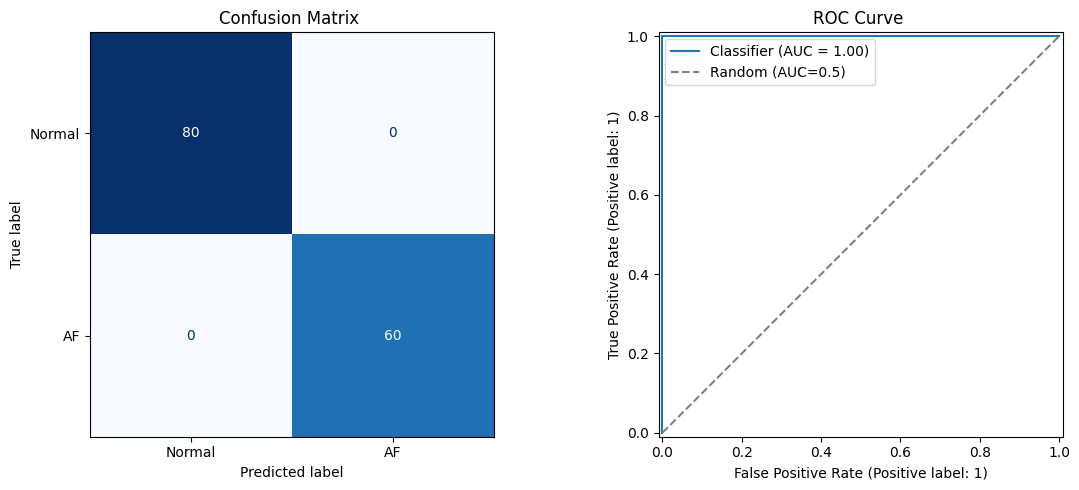

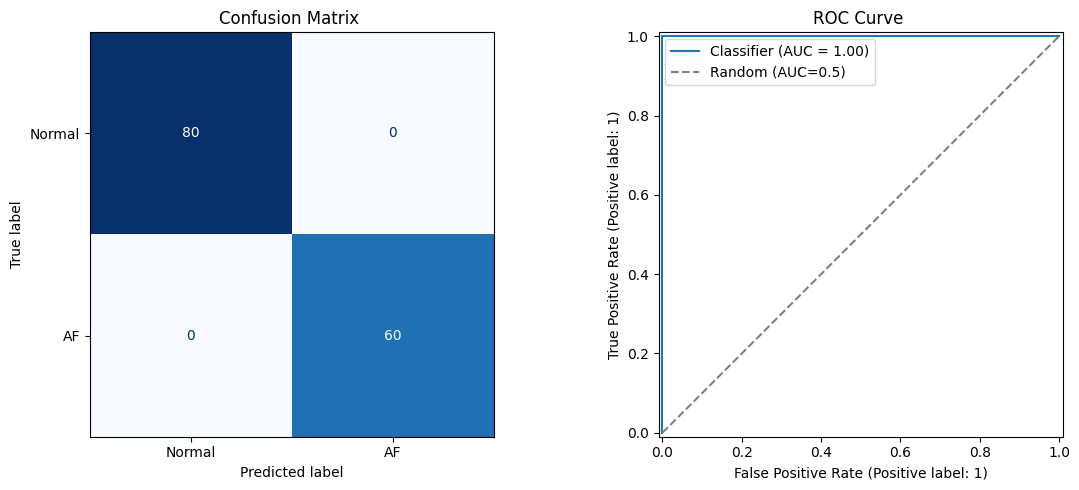

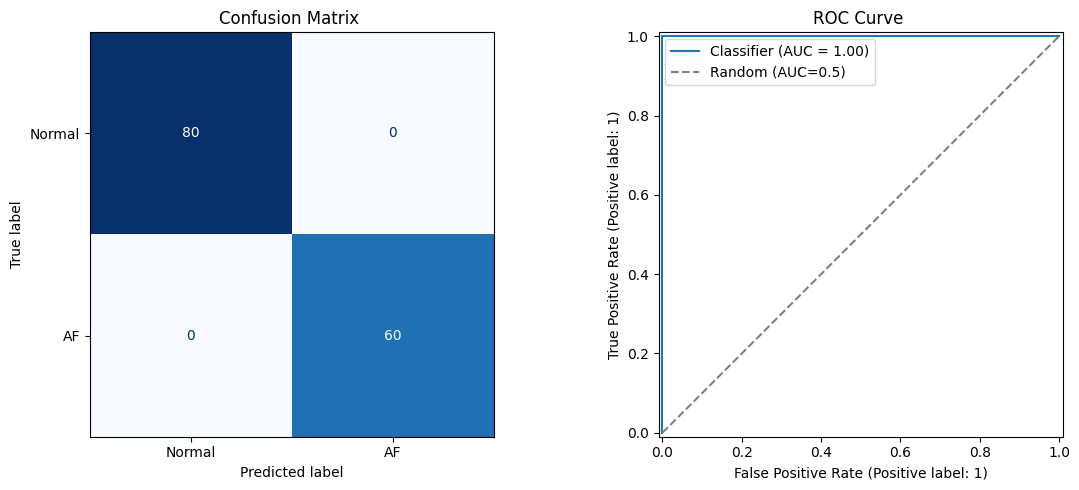

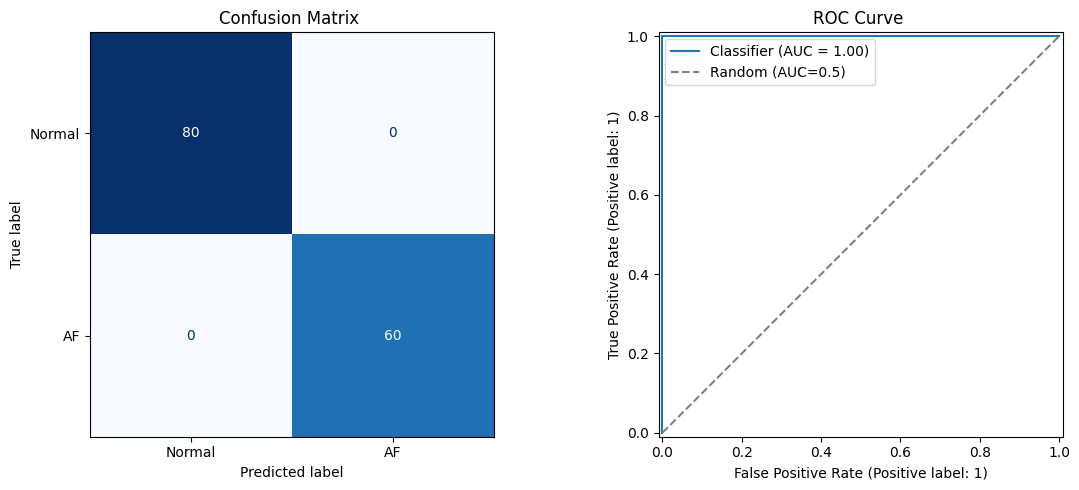

: 

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

results = [
    ("Original", y_test, y_proba, cm),
    ("Filtered 10dB", y_test, y_proba_filt_10dB, cm_filt_10dB),
    ("Filtered 20dB", y_test, y_proba_filt_20dB, cm_filt_20dB),
    ("No PCA", y_test, y_proba_no_pca, cm_no_pca)
]

for name, y_true, y_score, conf_matrix in results:
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion Matrix on the left with custom labels
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Normal", "AF"])
    disp.plot(values_format='d', cmap='Blues', ax=axs[0], colorbar=False)
    axs[0].set_title(f"Confusion Matrix ")

    # ROC Curve on the right
    RocCurveDisplay.from_predictions(y_true, y_score, ax=axs[1])
    axs[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC=0.5)')
    axs[1].legend()
    axs[1].set_title(f"ROC Curve ")

    plt.tight_layout()
    plt.show()


In [17]:
# Construir DataFrame
results_df = pd.DataFrame({
    'BSPs Data': ['Original', 'Filtered 10 dB', 'Filtered 20 dB', 'Original (No PCA)'],
    'Accuracy': [acc, acc_filt_10dB, acc_filt_20dB, acc_no_pca],
    'F1 Score': [f1_score_, f1_score_filt_10dB, f1_score_filt_20dB, f1_score_no_pca],
    'Sensitivity': [sensitivity, sensitivity_filt_10dB, sensitivity_filt_20dB, sensitivity_no_pca],
    'Specificity': [specificity, specificity_filt_10dB, specificity_filt_20dB, specificity_no_pca],
    'AUC-ROC': [roc_auc, roc_auc_filt_10dB, roc_auc_filt_20dB, roc_auc_no_pca],
    'Log Loss': [log_loss_, log_loss_filt_10dB, log_loss_filt_20dB, log_loss_no_pca]
})
results_df_transposed = results_df.set_index('BSPs Data').T.round(4)
print(results_df_transposed)

BSPs Data    Original  Filtered 10 dB  Filtered 20 dB  Original (No PCA)
Accuracy       1.0000          1.0000          1.0000             1.0000
F1 Score       1.0000          1.0000          1.0000             1.0000
Sensitivity    1.0000          1.0000          1.0000             1.0000
Specificity    1.0000          1.0000          1.0000             1.0000
AUC-ROC        1.0000          1.0000          1.0000             1.0000
Log Loss       0.0383          0.0691          0.0559             0.0187


In [18]:
from tabulate import tabulate
print(tabulate((results_df.round(4)).T, headers='keys', tablefmt='fancy_grid', showindex=False))

╒══════════╤════════════════╤════════════════╤═══════════════════╕
│ 0        │ 1              │ 2              │ 3                 │
╞══════════╪════════════════╪════════════════╪═══════════════════╡
│ Original │ Filtered 10 dB │ Filtered 20 dB │ Original (No PCA) │
├──────────┼────────────────┼────────────────┼───────────────────┤
│ 1.0      │ 1.0            │ 1.0            │ 1.0               │
├──────────┼────────────────┼────────────────┼───────────────────┤
│ 1.0      │ 1.0            │ 1.0            │ 1.0               │
├──────────┼────────────────┼────────────────┼───────────────────┤
│ 1.0      │ 1.0            │ 1.0            │ 1.0               │
├──────────┼────────────────┼────────────────┼───────────────────┤
│ 1.0      │ 1.0            │ 1.0            │ 1.0               │
├──────────┼────────────────┼────────────────┼───────────────────┤
│ 1.0      │ 1.0            │ 1.0            │ 1.0               │
├──────────┼────────────────┼────────────────┼────────────────

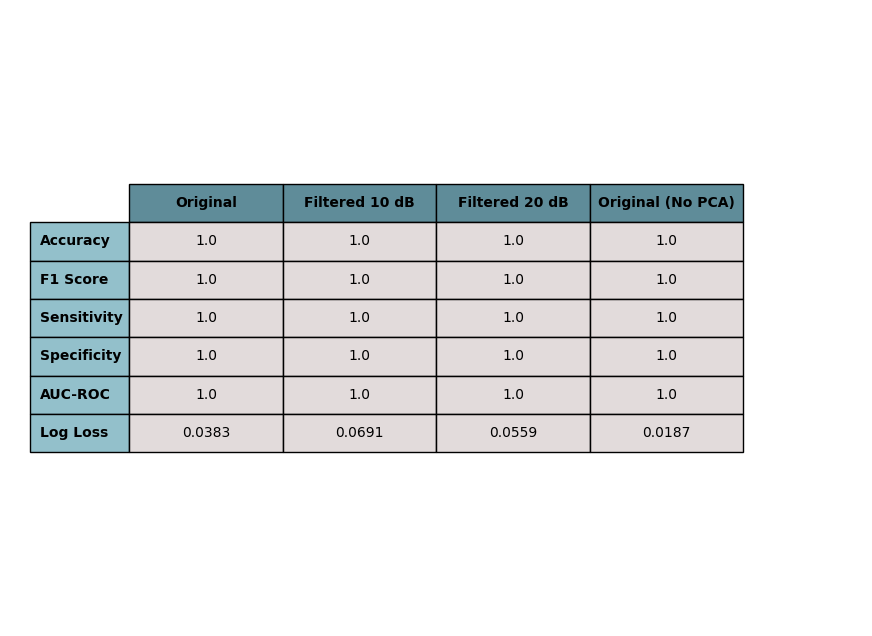

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

# Datos de ejemplo (rellena con tus variables reales)
metrics_dict = {
    'Original': {
        'Accuracy': acc,
        'F1 Score': f1_score_,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'AUC-ROC': roc_auc,
        'Log Loss': log_loss_,
    },
    'Filtered 10 dB': {
        'Accuracy': acc_filt_10dB,
        'F1 Score': f1_score_filt_10dB,
        'Sensitivity': sensitivity_filt_10dB,
        'Specificity': specificity_filt_10dB,
        'AUC-ROC': roc_auc_filt_10dB,
        'Log Loss': log_loss_filt_10dB,
    },
    'Filtered 20 dB': {
        'Accuracy': acc_filt_20dB,
        'F1 Score': f1_score_filt_20dB,
        'Sensitivity': sensitivity_filt_20dB,
        'Specificity': specificity_filt_20dB,
        'AUC-ROC': roc_auc_filt_20dB,
        'Log Loss': log_loss_filt_20dB,
    },
    'Original (No PCA)': {
        'Accuracy': acc_no_pca,
        'F1 Score': f1_score_no_pca,
        'Sensitivity': sensitivity_no_pca,
        'Specificity': specificity_no_pca,
        'AUC-ROC': roc_auc_no_pca,
        'Log Loss': log_loss_no_pca,
    },
}

import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

# Crear el DataFrame y redondear
df_metrics = pd.DataFrame(metrics_dict).round(4)

# Crear figura y tabla
fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off')
tbl = table(ax, df_metrics, loc='center', cellLoc='center', colWidths=[0.15]*df_metrics.shape[1])

# Estética general
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.3)

# Aplicar estilo a encabezados
for (row, col), cell in tbl.get_celld().items():
    if row == 0:  # encabezados
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor("#5f8c99")  # gris claro
    elif col == -1:  # fila de índices (las métricas)
        cell.set_text_props(weight='bold')
        cell.set_facecolor("#93c0cb")

    else:
        cell.set_facecolor("#dbd2d2cc")

# Guardar imagen
plt.savefig("styled_metrics_table.png", bbox_inches='tight', dpi=300)
plt.show()
